# Chapter 3 — Probability Topics

Probability as long-run frequency, and the rules for combining events.

| Section | What it covers |
|---|---|
| 3.1 | Chance and long-run frequency |
| 3.2 | Events, unions, intersections |
| 3.3 | Conditional probability and contingency tables |

**How to use this notebook.** Read a short explanation, run the worked cell under it, then do the
**Your turn** cell yourself. The worked cells already show their output, so you can check your
answer against them. Nothing here is graded and nothing is hidden, so break things freely and
re-run the setup cell if you get lost.

The matching page on the website is [Probability Topics](https://khh-aka-lucifer.github.io/statLab/chapters/probability-topics/), where the same ideas are
sliders and draggable points instead of code. Use both. The website builds the intuition, and the
notebook shows you how to do it to data of your own.

In [1]:
# Run me first. Everything below needs this cell.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# The same colours the StatLab website uses, so your charts match the demos.
C = {
    "accent": "#2E7D6B", "accent_strong": "#1F5A4D", "accent_soft": "#D9EBE5",
    "ink": "#282725", "ink_soft": "#6B6560", "line": "#E4E0DA",
    "cat1": "#2E7D6B", "cat2": "#B5763F", "cat3": "#4E7DA6",
    "cat4": "#9A5D8F", "cat5": "#8A8F3C",
    "ok": "#4C8B57", "warn": "#C06A2E",
}

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": C["line"], "axes.labelcolor": C["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C["line"], "grid.linewidth": 0.8,
    "text.color": C["ink"], "xtick.color": C["ink_soft"], "ytick.color": C["ink_soft"],
    "font.size": 11, "axes.titlesize": 12, "legend.frameon": False,
})

# Works whether you launched Jupyter inside code/ or at the repo root.
DATA = Path("data") if Path("data").exists() else Path("code/data")

# One seed, so your numbers match the text. Change it and the randomness changes with you.
rng = np.random.default_rng(12345)

print("Ready. pandas", pd.__version__, "| numpy", np.__version__)

Ready. pandas 3.0.3 | numpy 2.4.4


## Meet the passengers

Eight hundred and ninety-one passengers of the RMS Titanic, with the class they travelled in, their
age, sex, fare, and whether they survived. It is a hundred-year-old public record, and it is a good
data set for probability because every question you can ask about it is a real question that
mattered to a real person.

In [2]:
titanic = pd.read_csv(DATA / "titanic.csv")

print(titanic.shape)
titanic[["survived", "pclass", "sex", "age", "fare", "class", "embark_town"]].head()

(891, 15)


,survived,pclass,sex,age,fare,class,embark_town
0,0,3,male,22.0,7.2500,Third,Southampton
1,1,1,female,38.0,71.2833,First,Cherbourg
2,1,3,female,26.0,7.9250,Third,Southampton
3,1,1,female,35.0,53.1000,First,Southampton
4,0,3,male,35.0,8.0500,Third,Southampton


## 3.1 Chance and long-run frequency

Flip a coin once and you cannot say what it will show. Flip it a thousand times and you can say,
quite precisely, what fraction will be heads. **Probability** is that long-run fraction.

Watch it settle. The line wanders wildly at first and then stops wandering, without ever landing
exactly on 0.5 and staying there.

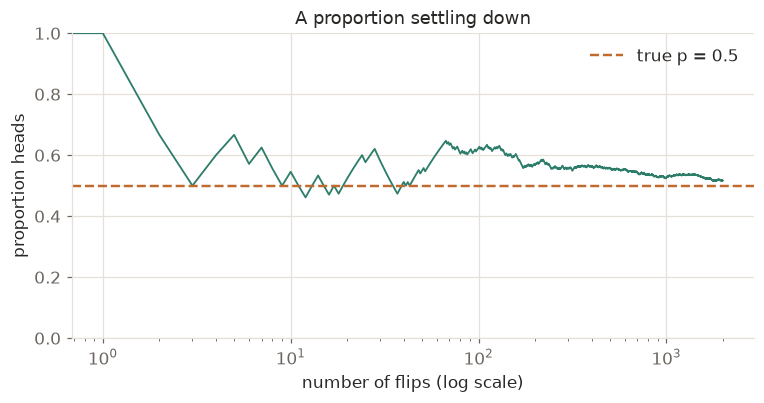

In [3]:
flips = rng.random(2000) < 0.5                 # True is heads
running = np.cumsum(flips) / np.arange(1, len(flips) + 1)

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(running, color=C["accent"], lw=1.2)
ax.axhline(0.5, color=C["warn"], ls="--", lw=1.6, label="true p = 0.5")
ax.set_xscale("log")

ax.set_xlabel("number of flips (log scale)"); ax.set_ylabel("proportion heads")
ax.set_ylim(0, 1); ax.set_title("A proportion settling down")
ax.legend()
plt.show()

The same thing happens with real data. If you did not know the survival rate and read the passenger
list one name at a time, your running estimate would settle the same way.

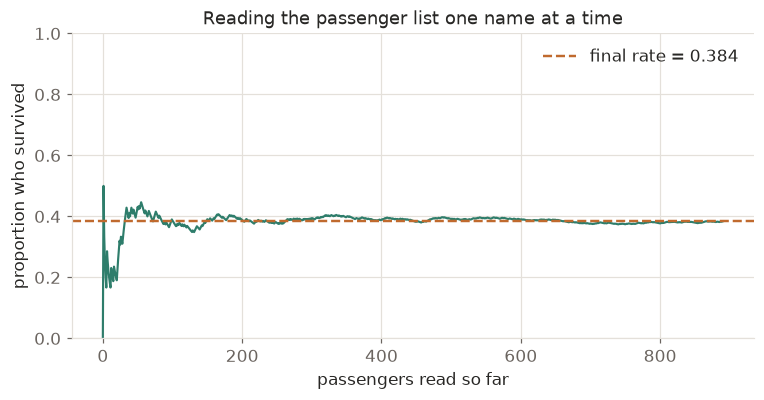

In [4]:
order = titanic["survived"].sample(frac=1, random_state=3).to_numpy()   # read the list in a random order
running = np.cumsum(order) / np.arange(1, len(order) + 1)

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(running, color=C["accent"], lw=1.4)
ax.axhline(titanic["survived"].mean(), color=C["warn"], ls="--", lw=1.6,
           label=f"final rate = {titanic['survived'].mean():.3f}")

ax.set_xlabel("passengers read so far"); ax.set_ylabel("proportion who survived")
ax.set_ylim(0, 1); ax.set_title("Reading the passenger list one name at a time")
ax.legend()
plt.show()

In [5]:
print(f"P(survived) = {titanic['survived'].mean():.4f}")
print(f"  that is {titanic['survived'].sum()} of {len(titanic)} passengers")

P(survived) = 0.3838
  that is 342 of 891 passengers


In [ ]:
# Your turn.
# Estimate P(survived) from only the first 50 passengers in a random order, then 200, then all 891.
# Do it for three different random orders. How wrong can 50 passengers be?

for seed in [1, 2, 3]:
    ...

## 3.2 Events, unions, intersections

An **event** is a set of outcomes. Write $P(A)$ for the probability of event $A$.

The **intersection** "$A$ and $B$" needs both to happen. The **union** "$A$ or $B$" needs at least
one. The **complement** of $A$ is everything else, and $P(\text{not } A) = 1 - P(A)$.

The one rule worth memorising is the addition rule, because the naive version double-counts.

$$P(A \text{ or } B) = P(A) + P(B) - P(A \text{ and } B)$$

In [6]:
female = titanic["sex"] == "female"
first  = titanic["class"] == "First"

p_f    = female.mean()
p_1    = first.mean()
p_both = (female & first).mean()
p_or   = (female | first).mean()

print(f"P(female)                = {p_f:.4f}")
print(f"P(first class)           = {p_1:.4f}")
print(f"P(female and first)      = {p_both:.4f}")
print(f"P(female or first)       = {p_or:.4f}")
print()
print(f"P(f) + P(1) - P(both)    = {p_f + p_1 - p_both:.4f}   <- the addition rule")
print(f"P(f) + P(1)              = {p_f + p_1:.4f}   <- wrong, double counts the overlap")

P(female)                = 0.3524
P(first class)           = 0.2424
P(female and first)      = 0.1055
P(female or first)       = 0.4893

P(f) + P(1) - P(both)    = 0.4893   <- the addition rule
P(f) + P(1)              = 0.5948   <- wrong, double counts the overlap


The two agree to the last decimal, because the rule is not an approximation. Subtracting the
intersection removes exactly the passengers counted twice, the women in first class.

Two events are **mutually exclusive** when they cannot both happen, so $P(A \text{ and } B) = 0$ and
the subtraction does nothing. Travelling first class and travelling third class are mutually
exclusive. Being female and travelling first class are not.

In [7]:
third = titanic["class"] == "Third"

print(f"P(first and third) = {(first & third).mean():.4f}   <- mutually exclusive")
print(f"P(first or third)  = {(first | third).mean():.4f}")
print(f"P(first) + P(third) = {first.mean() + third.mean():.4f}   <- here adding is safe")

P(first and third) = 0.0000   <- mutually exclusive
P(first or third)  = 0.7935
P(first) + P(third) = 0.7935   <- here adding is safe


In [ ]:
# Your turn.
# Let A be "travelled alone" (the `alone` column) and B be "embarked at Southampton"
# (embark_town == "Southampton").
# Compute P(A), P(B), P(A and B), P(A or B) from the data, then check the addition rule holds.

...

## 3.3 Conditional probability and contingency tables

The question that matters is rarely "what fraction survived". It is "what fraction of *this group*
survived". That is a **conditional probability**, written $P(A \mid B)$ and read "$A$ given $B$".

$$P(A \mid B) = \frac{P(A \text{ and } B)}{P(B)}$$

A **contingency table** is the whole calculation laid out at once.

In [8]:
table = pd.crosstab(titanic["sex"], titanic["survived"], margins=True, margins_name="total")
table.columns = ["died", "survived", "total"]
table

,died,survived,total
sex,,,
female,81,233,314
male,468,109,577
total,549,342,891


In [9]:
p_survived_given_female = (female & (titanic["survived"] == 1)).mean() / female.mean()
p_survived_given_male   = ((~female) & (titanic["survived"] == 1)).mean() / (~female).mean()

print(f"P(survived)               = {titanic['survived'].mean():.4f}")
print(f"P(survived | female)      = {p_survived_given_female:.4f}")
print(f"P(survived | male)        = {p_survived_given_male:.4f}")

P(survived)               = 0.3838
P(survived | female)      = 0.7420
P(survived | male)        = 0.1889


Overall, 38 % survived. Among women, 74 %. Among men, 19 %. Conditioning on sex changes the answer
by a factor of four, which is the entire point of conditional probability: the population rate can
be irrelevant to any individual in it.

Pandas will do the conditioning for you, and reading it as a table is easier than as three numbers.

In [10]:
pd.crosstab(titanic["sex"], titanic["survived"], normalize="index").round(4)

survived,0,1
sex,,
female,0.2580,0.7420
male,0.8111,0.1889


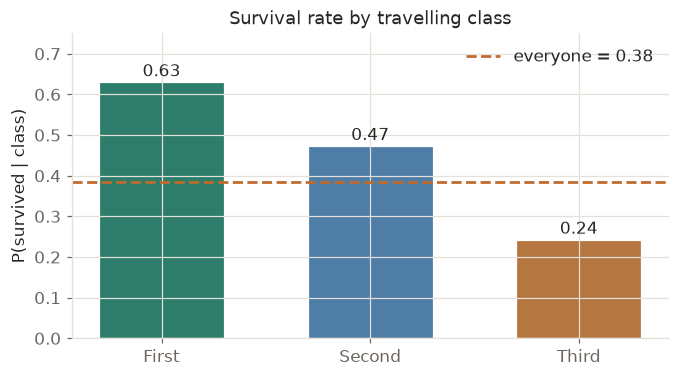

In [11]:
rates = pd.crosstab(titanic["class"], titanic["survived"], normalize="index")[1]

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(rates.index, rates.values, color=[C["accent"], C["cat3"], C["cat2"]],
       edgecolor="white", linewidth=0.8, width=0.6)
ax.axhline(titanic["survived"].mean(), color=C["warn"], ls="--", lw=1.8,
           label=f"everyone = {titanic['survived'].mean():.2f}")

for x, v in zip(rates.index, rates.values):
    ax.text(x, v + 0.015, f"{v:.2f}", ha="center", color=C["ink"])

ax.set_ylabel("P(survived | class)"); ax.set_ylim(0, 0.75)
ax.set_title("Survival rate by travelling class")
ax.legend()
plt.show()

### Independence

Two events are **independent** when knowing one tells you nothing about the other, which means
$P(A \mid B) = P(A)$. Equivalently, $P(A \text{ and } B) = P(A) \times P(B)$.

Almost nothing in real data is exactly independent. The useful question is how far from it you are.

In [12]:
def independence_check(name, a, b):
    joint    = (a & b).mean()
    separate = a.mean() * b.mean()
    print(f"{name:34s} P(A and B) = {joint:.4f}   P(A)P(B) = {separate:.4f}   "
          f"ratio = {joint / separate:.2f}")

survived = titanic["survived"] == 1
independence_check("female & survived", female, survived)
independence_check("first class & survived", first, survived)
independence_check("alone & embarked Southampton",
                   titanic["alone"].astype(bool), titanic["embark_town"] == "Southampton")

female & survived                  P(A and B) = 0.2615   P(A)P(B) = 0.1353   ratio = 1.93
first class & survived             P(A and B) = 0.1526   P(A)P(B) = 0.0931   ratio = 1.64
alone & embarked Southampton       P(A and B) = 0.4411   P(A)P(B) = 0.4356   ratio = 1.01


A ratio of 1 would mean exact independence. Being female and surviving comes out at 1.93, so those
two events happened together nearly twice as often as independence predicts. Travelling alone and
boarding at Southampton sits at 1.05, close enough to independent that the departure port tells you
almost nothing about whether someone travelled alone.

Chapter 11 turns that ratio into a formal test with a p-value. For now, noticing the gap is enough.

In [ ]:
# Your turn.
# Build the contingency table of `class` against `sex` and answer:
# 1. P(first class | female)
# 2. P(female | first class)
# These two are different numbers. Explain in a comment why, in plain words.

...

## Exercises

1. **The children.** Add a column for "was a child", meaning `age < 16`. Compute
   $P(\text{survived} \mid \text{child})$ and compare it against adults. Then do it separately for
   each class. Does the "women and children first" rule show up equally in all three classes?

2. **Missing ages.** 177 passengers have no recorded age. Compute the survival rate for passengers
   with a recorded age and for those without. If they differ, what does that tell you about how the
   record was compiled, and should you worry?

3. **Three-way conditioning.** Find $P(\text{survived} \mid \text{female and third class})$ and
   compare it with $P(\text{survived} \mid \text{male and first class})$. Which mattered more on
   that night, sex or class?

4. **Build the addition rule yourself.** Pick any two columns, compute both sides of
   $P(A \text{ or } B) = P(A) + P(B) - P(A \text{ and } B)$, and confirm they match. Then break it
   on purpose by forgetting the last term, and measure how far off you are.

5. **Simulate independence.** Shuffle the `survived` column so it has no connection to anything.
   Recompute the independence ratios from this section on the shuffled data. How close to 1 do they
   get, and how much do they bounce around between shuffles? That bouncing is what Chapter 11 has to
   tell signal from.

## What you should take away

Probability is a long-run fraction, and you can watch it settle by simulating or by reading real
records one at a time. It never lands exactly on the true value and stays there. It just wanders
less and less.

The addition rule subtracts the overlap because otherwise you count it twice. Conditioning restricts
attention to a subgroup and can change an answer beyond recognition, as 38 % becoming 74 % or 19 %
shows. And independence is the special case where conditioning changes nothing, which real data
almost never delivers exactly.

---

*StatLab, by Dr. Sein Minn and Kaung Hein Htet. Code MIT, text CC BY 4.0.
Follows OpenStax [Introductory Statistics](https://openstax.org) (Illowsky & Dean, CC BY 4.0).*